In [1]:
import DataMakar
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

import cartopy.crs as ccrs

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packa

In [2]:
ssplist = ["126","245","370","585"]

# set user parameters

experiment_era = [1950,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 10

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]



In [3]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [4]:
def confacc(predclass,trueclass,predconf):

    predcorr = predclass==trueclass
    percentiles = np.arange(0,100,5)
    accper = np.empty(20)
    for iper,per in enumerate(percentiles):

        perboo = np.percentile(predconf,per)
        accper[iper] = np.mean(predcorr[predconf>perboo])

    return accper

def firstpositive(pred,gmtvec):
    if np.sum(pred[pred>0.5])>1:
        firstpos = np.min(gmtvec[pred>0.5])
    else:
        firstpos = np.nan
    return firstpos

def firstconfident(pred,gmtvec):

    conf = np.where(pred<0.5,1-pred,pred)
    percentile = np.percentile(conf,50)
    if np.sum(1*((pred>0.5) & (conf>percentile)))>0:
        firstconf = np.min(gmtvec[(pred>0.5) & (conf>percentile)])
    else:
        firstconf = np.nan
    return firstconf

def firstcorrect(pred,true,gmtvec):
    predclass = np.round(pred)
    if np.sum((predclass==1) & (true==1))>0:
        firstcorrect = np.min(gmtvec[(predclass==1) & (true==1)])
    else:
        firstcorrect = np.nan
    return firstcorrect
    
def grabssp(data,issp,lenhist,lenfuture,nmems):

    if issp == 0:
        dataout = data[:nmems*lenhist,]
    else:
        dataout = data[nmems*(lenhist+(issp-1)*lenfuture):nmems*(lenhist+(issp)*lenfuture),]
    
    return dataout

In [29]:
ilatsel = 9
ilonsel = 2

latsel = latvec[ilatsel]
lonsel = lonvec[ilonsel]

In [30]:


# trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)
# trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

# trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)
trainvaltest = [np.arange(25),np.arange(25,38),test]

alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

inputtrain, inputtrainGMT,outputtrainall = DataHolder.tensortime_onehot(alltrain,nclasses=2)
inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)

outputtrain = np.argmax(outputtrainall.numpy(),axis=1)
outputtest = np.argmax(outputtest.numpy(),axis=1)

inputssptrain,inputsspval,inputssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,latsel)

inputalltrain = np.concatenate((inputtrainGMT.numpy(),inputssptrain),axis=1)
inputalltest = np.concatenate((inputtestGMT.numpy(),inputssptest),axis=1)

baseline for gmt is 60 90
experiment era in the historical is 50 124
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:1470: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


In [31]:
testfileout = "metrics/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon"+str(lonsel)+"_testing.json"
fileload = glob.glob(testfileout)

with open(testfileout, "r") as f:
    data = json.load(f)
    bestaccs = np.array(data["test_accuracy"])
    nulls = np.max(np.array(data["test_class_imbalance"]))

filepredictions = "predictions/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_testing.pkl"

with open(filepredictions,'rb') as f:
    predictions = pickle.load(f)

filetrue = "predictions/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_truetesting.pkl"

with open(filetrue,'rb') as f:
    truths = pickle.load(f)

avgtestpred = np.mean(predictions,axis=1)
avgtestclass = np.round(avgtestpred)
avgtestconf = np.where(avgtestpred<0.5,1-avgtestpred,avgtestpred)

bs_cnn = np.mean((avgtestpred[ilonsel]-truths[ilonsel])**2)


In [39]:
lr_model = LogisticRegression()
lr_model.fit(inputalltrain,outputtrain)

y_pred = lr_model.predict(inputalltest)
y_pred_probs = lr_model.predict_proba(inputalltest)

bs_lr = (truths[ilonsel]-y_pred_probs[:,1])**2

In [33]:
meantest = np.mean(truths[ilonsel])
meantest

0.3856998992950655

In [40]:
bs_lr

array([0.02026824, 0.02010918, 0.01968468, ..., 0.71491482, 0.0222513 ,
       0.02012501])

In [38]:
truths.shape

(36, 3972)

In [37]:
bs_lr

0.20997943687315904

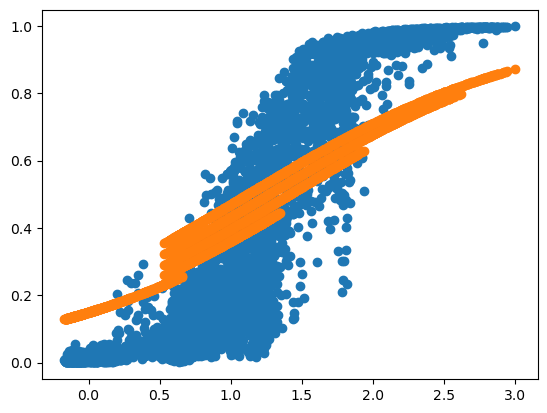

In [12]:
plt.scatter(inputtestGMT.numpy().squeeze(),avgtestpred[ilonsel])
plt.scatter(inputtestGMT.numpy().squeeze(),y_pred_probs[:,1])

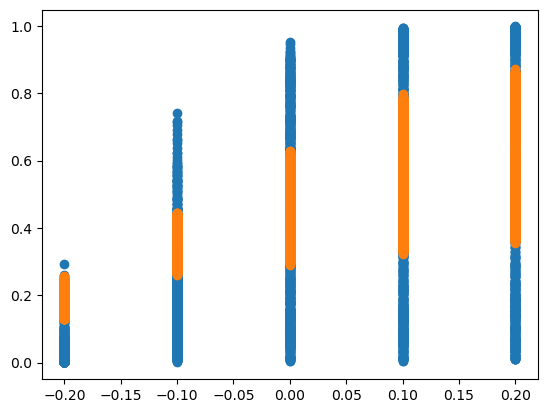

In [13]:
plt.scatter(inputssptest.squeeze(),avgtestpred[ilonsel])
plt.scatter(inputssptest.squeeze(),y_pred_probs[:,1])

In [14]:
np.mean((avgtestclass[int(lonsel/10)]==outputtest) & (outputtest==0))

0.4786002014098691

In [15]:
np.mean((y_pred==outputtest) & (outputtest==0))

0.4919436052366566

In [16]:
def roc_curve_code(y_true,y_pred,):

    confs = np.flipud(np.sort(y_pred))[1:]
    # y_pred_class = np.round(y_pred)

    tprs = []
    fprs = []

    for ithres,thres in enumerate(confs):

        y_predsel = y_pred>thres

        # y_predsel = y_pred_class[boo]
        # y_truesel = y_true[boo]

        tp = np.mean((y_predsel==1) & (y_true==1))
        fp = np.mean((y_predsel==1) & (y_true==0))

        tn = np.mean((y_predsel==0) & (y_true==0))
        fn = np.mean((y_predsel==0) & (y_true==1))

        tpr = tp/(tp+fn)
        fpr = fp/(tn+fp)

        tprs.append(tpr)
        fprs.append(fpr)

    return fprs,tprs,confs


In [17]:
def compute_roc_curve(y_true, y_scores):
    """
    Manually compute ROC curve
    
    Parameters:
    y_true: array of true binary labels (0 or 1)
    y_scores: array of prediction scores/probabilities
    
    Returns:
    fpr: false positive rates
    tpr: true positive rates
    thresholds: decision thresholds
    """
    
    # Get unique thresholds (sorted in descending order)
    thresholds = np.unique(y_scores)
    thresholds = np.sort(thresholds)[::-1]
    
    # Initialize arrays
    fpr = []
    tpr = []
    
    # Calculate TPR and FPR for each threshold
    for threshold in thresholds:
        # Make predictions based on threshold
        y_pred = (y_scores >= threshold).astype(int)
        
        # Calculate confusion matrix components
        tp = np.sum((y_pred == 1) & (y_true == 1))  # True Positives
        fp = np.sum((y_pred == 1) & (y_true == 0))  # False Positives
        tn = np.sum((y_pred == 0) & (y_true == 0))  # True Negatives
        fn = np.sum((y_pred == 0) & (y_true == 1))  # False Negatives
        
        # Calculate rates
        tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity/Recall
        fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0  # 1 - Specificity
        
        tpr.append(tpr_val)
        fpr.append(fpr_val)
    
    # Add endpoints
    fpr = [0] + fpr + [1]
    tpr = [0] + tpr + [1]
    thresholds = [float('inf')] + list(thresholds) + [float('-inf')]
    
    return np.array(fpr), np.array(tpr), np.array(thresholds)

In [18]:
fprs,tprs,confs = roc_curve(outputtest,avgtestpred[int(lonsel/10)])    

In [19]:
fprs2,tprs2,confs2 = roc_curve_code(outputtest,avgtestpred[int(lonsel/10)])

In [20]:
fprs3,tprs3,confs3 = compute_roc_curve(outputtest,avgtestpred[int(lonsel/10)])

In [21]:
fpr_lr,tpr_lr,confs_lr = roc_curve_code(outputtest,y_pred_probs[:,1])

In [22]:
np.mean((y_pred_probs[:,1]-outputtest)**2)

0.20997943687315904

In [23]:
np.mean((avgtestpred[int(lonsel/10)]-outputtest)**2)

0.2247165355344442

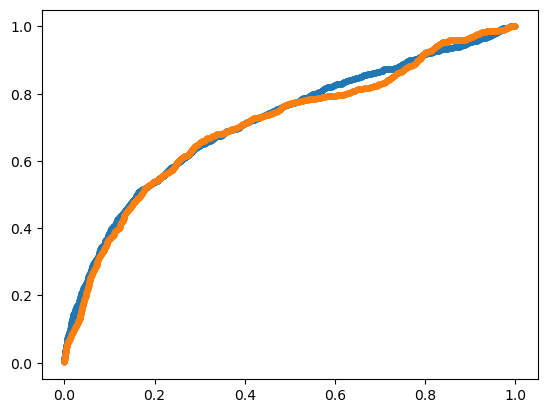

In [24]:
plt.scatter(fprs2,tprs2,marker='.')
plt.scatter(fpr_lr,tpr_lr,marker='.')

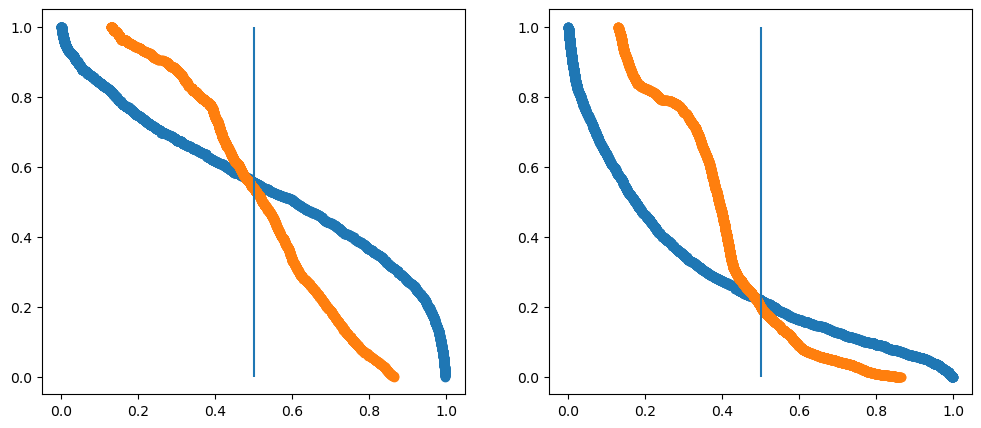

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1,)
plt.scatter(confs2,tprs2)
plt.scatter(confs_lr,tpr_lr)
plt.vlines(0.5,0,1)

plt.subplot(1,2,2,)
plt.scatter(confs2,fprs2)
plt.scatter(confs_lr,fpr_lr)
plt.vlines(0.5,0,1)

In [26]:
np.min(tpr_lr)

0.0006527415143603133

In [27]:
tprs[0]

0.0